# Predicting Energy Use in a Smart Home

## Objectives
- Predict total energy consumption (appliances + lights) in a smart home
- Identify key environmental and time-based factors affecting energy use
- Filter non-predictive features to improve model accuracy

## Data Pipeline
1. Data Loading
2. Data Preparation & Feature Engineering
3. Train / Test Split
4. EDA: Training Data
5. EDA: Validation Data
6. Model Building
7. Results & Inference

In [1]:
#Required imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import RFE
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

In [2]:
# 1. Data Loading
# Loading the dataset
df = pd.read_csv('energydata_complete.csv')


print(df.shape)
df.head()

(19735, 29)


,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


In [3]:
# Checking data types and null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 29 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         19735 non-null  object 
 1   Appliances   19735 non-null  int64  
 2   lights       19735 non-null  int64  
 3   T1           19735 non-null  float64
 4   RH_1         19735 non-null  float64
 5   T2           19735 non-null  float64
 6   RH_2         19735 non-null  float64
 7   T3           19735 non-null  float64
 8   RH_3         19735 non-null  float64
 9   T4           19735 non-null  float64
 10  RH_4         19735 non-null  float64
 11  T5           19735 non-null  float64
 12  RH_5         19735 non-null  float64
 13  T6           19735 non-null  float64
 14  RH_6         19735 non-null  float64
 15  T7           19735 non-null  float64
 16  RH_7         19735 non-null  float64
 17  T8           19735 non-null  float64
 18  RH_8         19735 non-null  float64
 19  T9  

In [4]:
# Summary stats
df.describe().round(2)

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
count,19735.00,19735.00,19735.00,19735.00,19735.00,19735.00,19735.00,19735.00,19735.00,19735.00,...,19735.00,19735.00,19735.00,19735.00,19735.00,19735.00,19735.00,19735.00,19735.00,19735.00
mean,97.69,3.80,21.69,40.26,20.34,40.42,22.27,39.24,20.86,39.03,...,19.49,41.55,7.41,755.52,79.75,4.04,38.33,3.76,24.99,24.99
std,102.52,7.94,1.61,3.98,2.19,4.07,2.01,3.25,2.04,4.34,...,2.01,4.15,5.32,7.40,14.90,2.45,11.79,4.19,14.50,14.50
min,10.00,0.00,16.79,27.02,16.10,20.46,17.20,28.77,15.10,27.66,...,14.89,29.17,-5.00,729.30,24.00,0.00,1.00,-6.60,0.01,0.01
25%,50.00,0.00,20.76,37.33,18.79,37.90,20.79,36.90,19.53,35.53,...,18.00,38.50,3.67,750.93,70.33,2.00,29.00,0.90,12.50,12.50
50%,60.00,0.00,21.60,39.66,20.00,40.50,22.10,38.53,20.67,38.40,...,19.39,40.90,6.92,756.10,83.67,3.67,40.00,3.43,24.90,24.90
75%,100.00,0.00,22.60,43.07,21.50,43.26,23.29,41.76,22.10,42.16,...,20.60,44.34,10.41,760.93,91.67,5.50,40.00,6.57,37.58,37.58
max,1080.00,70.00,26.26,63.36,29.86,56.03,29.24,50.16,26.20,51.09,...,24.50,53.33,26.10,772.30,100.00,14.00,66.00,15.50,50.00,50.00


In [5]:
## 2. Data Preprocessing & Feature Engineering

## 2.1 Fix datatypes
# Convert date from string to datetime
df['date'] = pd.to_datetime(df['date'])
print(df['date'].dtype)
df['date'].head()

datetime64[ns]


,date
0,2016-01-11 17:00:00
1,2016-01-11 17:10:00
2,2016-01-11 17:20:00
3,2016-01-11 17:30:00
4,2016-01-11 17:40:00


In [6]:
# 2.2 Feature Engineering
# Extract time-based features from date
df['month']      = df['date'].dt.month
df['day']        = df['date'].dt.day
df['hour']       = df['date'].dt.hour
df['weekday']    = df['date'].dt.weekday   # 0=Monday, 6=Sunday
df['is_weekend'] = (df['weekday'] >= 5).astype(int)

df[['date', 'month', 'day', 'hour', 'weekday', 'is_weekend']].head(10)

,date,month,day,hour,weekday,is_weekend
0,2016-01-11 17:00:00,1,11,17,0,0
1,2016-01-11 17:10:00,1,11,17,0,0
2,2016-01-11 17:20:00,1,11,17,0,0
3,2016-01-11 17:30:00,1,11,17,0,0
4,2016-01-11 17:40:00,1,11,17,0,0
5,2016-01-11 17:50:00,1,11,17,0,0
6,2016-01-11 18:00:00,1,11,18,0,0
7,2016-01-11 18:10:00,1,11,18,0,0
8,2016-01-11 18:20:00,1,11,18,0,0
9,2016-01-11 18:30:00,1,11,18,0,0


In [7]:
# Combine Appliances + lights into single target
df['Energy'] = df['Appliances'] + df['lights']

print(f'Appliances range : {df["Appliances"].min()} – {df["Appliances"].max()} Wh')
print(f'lights range     : {df["lights"].min()} – {df["lights"].max()} Wh')
print(f'Energy range     : {df["Energy"].min()} – {df["Energy"].max()} Wh')

Appliances range : 10 – 1080 Wh
lights range     : 0 – 70 Wh
Energy range     : 10 – 1110 Wh


In [8]:
# Renaming temperature and humidity cols to reflect their room
rename_map = {
    'T1': 'kitchen_temp',       'RH_1': 'kitchen_hum',
    'T2': 'living_room_temp',   'RH_2': 'living_room_hum',
    'T3': 'laundry_temp',       'RH_3': 'laundry_hum',
    'T4': 'office_temp',        'RH_4': 'office_hum',
    'T5': 'bathroom_temp',      'RH_5': 'bathroom_hum',
    'T6': 'outside_n_temp',     'RH_6': 'outside_n_hum',
    'T7': 'ironing_temp',       'RH_7': 'ironing_hum',
    'T8': 'teen_room_temp',     'RH_8': 'teen_room_hum',
    'T9': 'parents_temp',       'RH_9': 'parents_hum',
    'T_out':       't_out',
    'RH_out':      'rh_out',
    'Press_mm_hg': 'pressure',
    'Windspeed':   'windspeed',
    'Visibility':  'visibility',
    'Tdewpoint':   'tdewpoint'
}
df = df.rename(columns=rename_map)
print(df.columns.tolist())

['date', 'Appliances', 'lights', 'kitchen_temp', 'kitchen_hum', 'living_room_temp', 'living_room_hum', 'laundry_temp', 'laundry_hum', 'office_temp', 'office_hum', 'bathroom_temp', 'bathroom_hum', 'outside_n_temp', 'outside_n_hum', 'ironing_temp', 'ironing_hum', 'teen_room_temp', 'teen_room_hum', 'parents_temp', 'parents_hum', 't_out', 'pressure', 'rh_out', 'windspeed', 'visibility', 'tdewpoint', 'rv1', 'rv2', 'month', 'day', 'hour', 'weekday', 'is_weekend', 'Energy']


In [9]:
# Droping date (already extracted), original targets, and random variables
df = df.drop(columns=['date', 'Appliances', 'lights', 'rv1', 'rv2'])

print(f'Shape after dropping: {df.shape}')
df.head()

Shape after dropping: (19735, 30)


,kitchen_temp,kitchen_hum,living_room_temp,living_room_hum,laundry_temp,laundry_hum,office_temp,office_hum,bathroom_temp,bathroom_hum,...,rh_out,windspeed,visibility,tdewpoint,month,day,hour,weekday,is_weekend,Energy
0,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,45.566667,17.166667,55.20,...,92.0,7.000000,63.000000,5.3,1,11,17,0,0,90
1,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,45.992500,17.166667,55.20,...,92.0,6.666667,59.166667,5.2,1,11,17,0,0,90
2,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,45.890000,17.166667,55.09,...,92.0,6.333333,55.333333,5.1,1,11,17,0,0,80
3,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,45.723333,17.166667,55.09,...,92.0,6.000000,51.500000,5.0,1,11,17,0,0,90
4,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,45.530000,17.200000,55.09,...,92.0,5.666667,47.666667,4.9,1,11,17,0,0,100


In [10]:
# 2.3 Train / Test Split (80/20)
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f'Training set  : {train_df.shape[0]:,} rows')
print(f'Validation set: {test_df.shape[0]:,} rows')

Training set  : 15,788 rows
Validation set: 3,947 rows


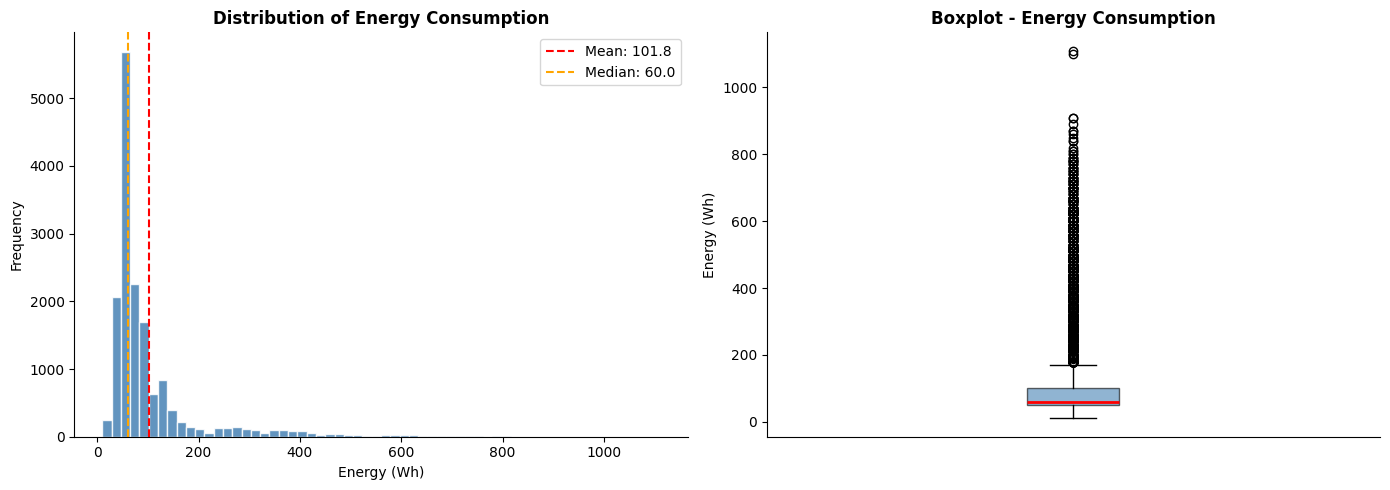

Mean   : 101.8 Wh
Median : 60.0 Wh
Skew   : 3.31


In [11]:
## 3. EDA on Training Data

# 3.1 Distribution of target variable (Energy)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(train_df['Energy'], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(train_df['Energy'].mean(),   color='red',    linestyle='--', linewidth=1.5,
                label=f'Mean: {train_df["Energy"].mean():.1f}')
axes[0].axvline(train_df['Energy'].median(), color='orange', linestyle='--', linewidth=1.5,
                label=f'Median: {train_df["Energy"].median():.1f}')
axes[0].set_title('Distribution of Energy Consumption', fontweight='bold')
axes[0].set_xlabel('Energy (Wh)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].boxplot(train_df['Energy'], patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Boxplot - Energy Consumption', fontweight='bold')
axes[1].set_ylabel('Energy (Wh)')
axes[1].set_xticks([])

plt.tight_layout()
plt.show()

print(f'Mean   : {train_df["Energy"].mean():.1f} Wh')
print(f'Median : {train_df["Energy"].median():.1f} Wh')
print(f'Skew   : {train_df["Energy"].skew():.2f}')

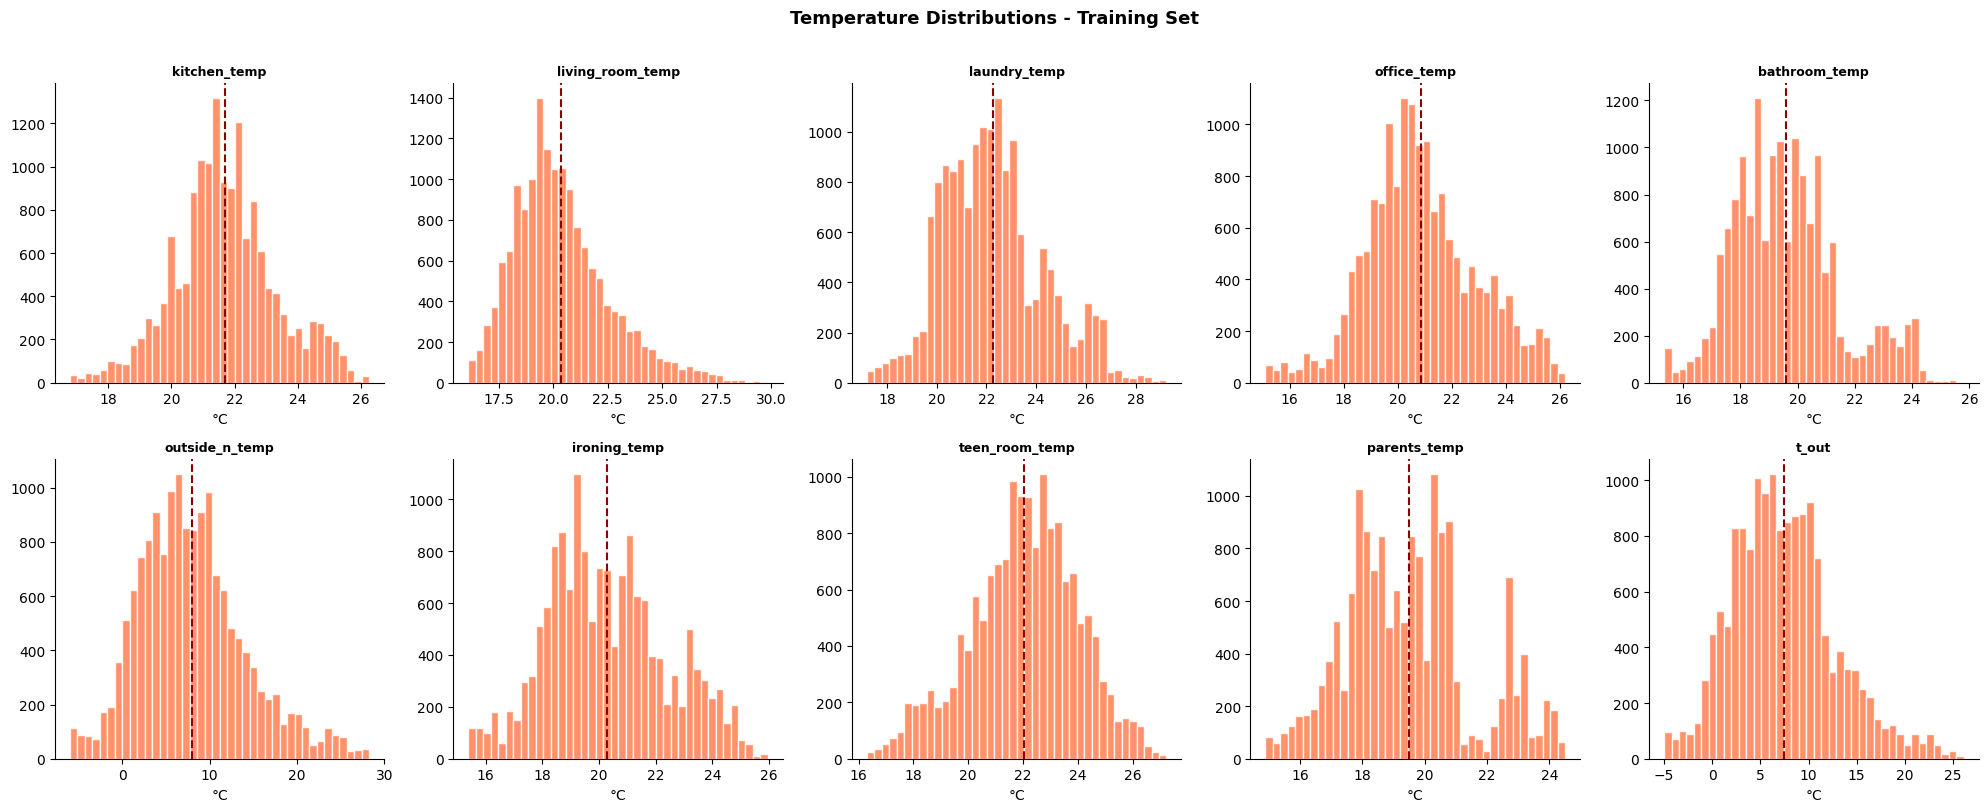

In [12]:
# 3.2 Distribution of temp features
temp_cols = ['kitchen_temp', 'living_room_temp', 'laundry_temp', 'office_temp',
             'bathroom_temp', 'outside_n_temp', 'ironing_temp', 'teen_room_temp',
             'parents_temp', 't_out']

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(temp_cols):
    axes[i].hist(train_df[col], bins=40, color='coral', edgecolor='white', alpha=0.85)
    axes[i].axvline(train_df[col].mean(), color='darkred', linestyle='--', linewidth=1.5)
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    axes[i].set_xlabel('°C')

plt.suptitle('Temperature Distributions - Training Set', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

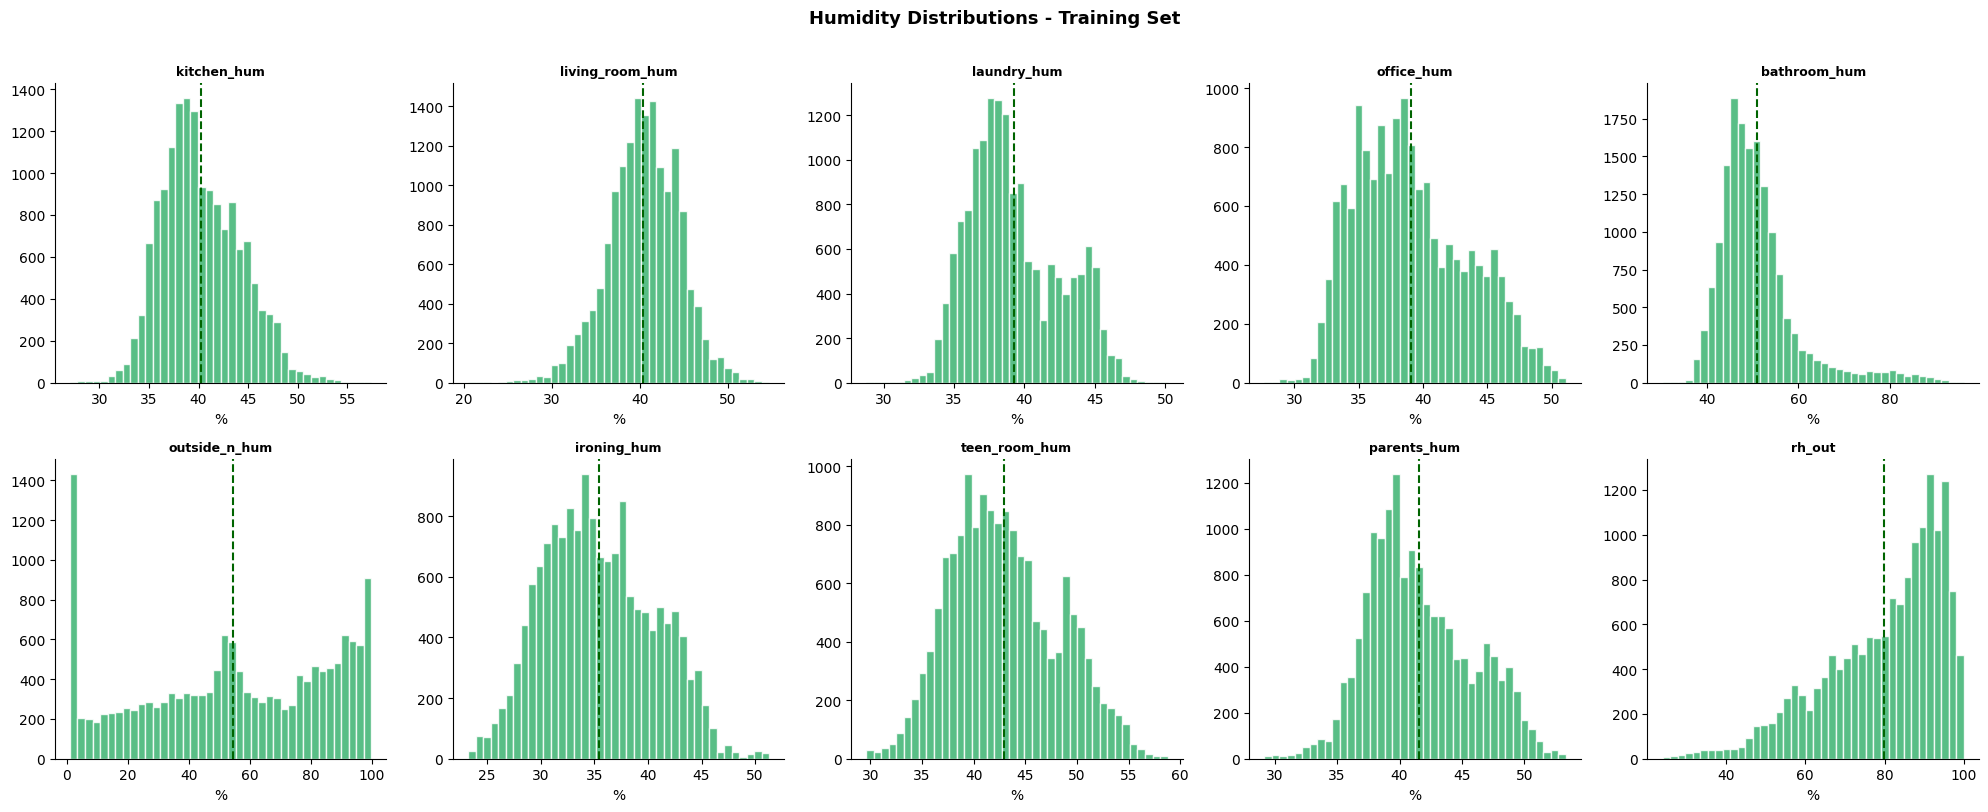

In [13]:
# 3.3 Distribution of humidity features
hum_cols = ['kitchen_hum', 'living_room_hum', 'laundry_hum', 'office_hum',
            'bathroom_hum', 'outside_n_hum', 'ironing_hum', 'teen_room_hum',
            'parents_hum', 'rh_out']

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(hum_cols):
    axes[i].hist(train_df[col], bins=40, color='mediumseagreen', edgecolor='white', alpha=0.85)
    axes[i].axvline(train_df[col].mean(), color='darkgreen', linestyle='--', linewidth=1.5)
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    axes[i].set_xlabel('%')

plt.suptitle('Humidity Distributions - Training Set', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

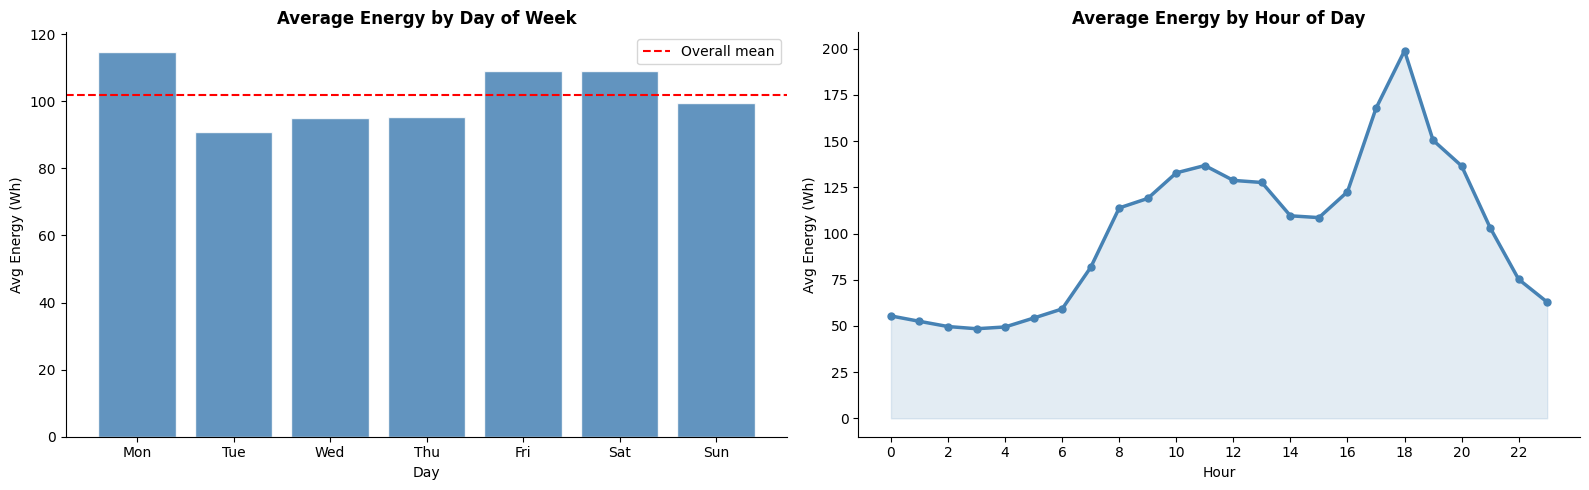

In [14]:
# 3.4 Energy consumption patterns by time
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# By day of week
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
daily_avg  = train_df.groupby('weekday')['Energy'].mean()
axes[0].bar(day_labels, daily_avg.values, color='steelblue', alpha=0.85, edgecolor='white')
axes[0].axhline(daily_avg.mean(), color='red', linestyle='--', linewidth=1.5, label='Overall mean')
axes[0].set_title('Average Energy by Day of Week', fontweight='bold')
axes[0].set_xlabel('Day')
axes[0].set_ylabel('Avg Energy (Wh)')
axes[0].legend()

# By hour
hourly_avg = train_df.groupby('hour')['Energy'].mean()
axes[1].plot(hourly_avg.index, hourly_avg.values, color='steelblue', linewidth=2.5, marker='o', markersize=5)
axes[1].fill_between(hourly_avg.index, hourly_avg.values, alpha=0.15, color='steelblue')
axes[1].set_title('Average Energy by Hour of Day', fontweight='bold')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Avg Energy (Wh)')
axes[1].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.show()

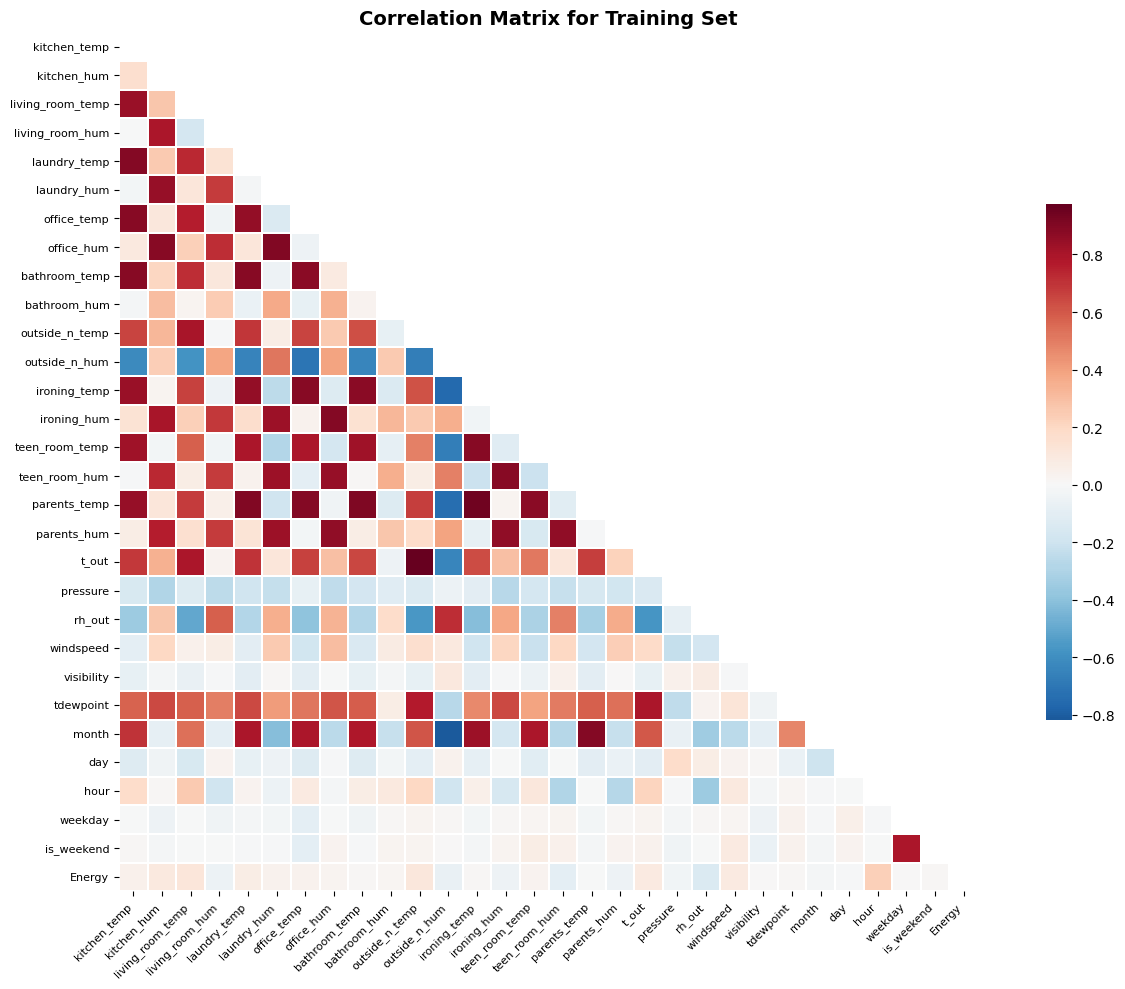

Top 10 correlations with Energy:
hour                0.230
rh_out             -0.142
living_room_temp    0.118
outside_n_temp      0.111
kitchen_hum         0.094
t_out               0.092
teen_room_hum      -0.090
windspeed           0.089
laundry_temp        0.076
outside_n_hum      -0.069
Name: Energy, dtype: float64


In [16]:
# 3.5 Correlation heatmap
corr = train_df.corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0,
            square=True, linewidths=0.3, cbar_kws={'shrink': 0.6})
plt.title('Correlation Matrix for Training Set', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

# Top correlations with Energy
target_corr = corr['Energy'].drop('Energy').sort_values(key=abs, ascending=False)
print('Top 10 correlations with Energy:')
print(target_corr.head(10).round(3))

In [17]:
# 3.6 Reduce temp features, replace 9 indoor sensors with one avg
indoor_temp_cols = ['kitchen_temp', 'living_room_temp', 'laundry_temp', 'office_temp',
                    'bathroom_temp', 'outside_n_temp', 'ironing_temp',
                    'teen_room_temp', 'parents_temp']

train_df['mean_indoor_temp'] = train_df[indoor_temp_cols].mean(axis=1)
train_df = train_df.drop(columns=indoor_temp_cols)

print(f'Replaced {len(indoor_temp_cols)} temperature columns with mean_indoor_temp')
print(f'Columns remaining: {train_df.shape[1]}')

Replaced 9 temperature columns with mean_indoor_temp
Columns remaining: 22


In [18]:
# Replace 9 indoor humidity sensors with one average, same multicollinearity reason
indoor_hum_cols = ['kitchen_hum', 'living_room_hum', 'laundry_hum', 'office_hum',
                   'bathroom_hum', 'outside_n_hum', 'ironing_hum',
                   'teen_room_hum', 'parents_hum']

train_df['mean_indoor_hum'] = train_df[indoor_hum_cols].mean(axis=1)
train_df = train_df.drop(columns=indoor_hum_cols)

print(f'Replaced {len(indoor_hum_cols)} humidity columns with mean_indoor_hum')
print(f'Columns remaining: {train_df.shape[1]}')
print(train_df.columns.tolist())

Replaced 9 humidity columns with mean_indoor_hum
Columns remaining: 14
['t_out', 'pressure', 'rh_out', 'windspeed', 'visibility', 'tdewpoint', 'month', 'day', 'hour', 'weekday', 'is_weekend', 'Energy', 'mean_indoor_temp', 'mean_indoor_hum']


In [19]:
# 3.7 Outlier detection using ±3 standard deviations
# Computing bounds on training data only, will apply same to test later
numeric_cols = train_df.select_dtypes(include=np.number).columns.difference(['Energy'])

outlier_bounds = {}

for col in numeric_cols:
    mean  = train_df[col].mean()
    std   = train_df[col].std()
    lower = mean - 3 * std
    upper = mean + 3 * std
    outlier_bounds[col] = (lower, upper)
    n_out = ((train_df[col] < lower) | (train_df[col] > upper)).sum()
    if n_out > 0:
        print(f'{col:20s}: {n_out:4d} outliers  [{lower:.2f}, {upper:.2f}]')

# Cap the outliers (winsorize)
for col, (lower, upper) in outlier_bounds.items():
    train_df[col] = train_df[col].clip(lower, upper)

print(f'\nDone. Training shape: {train_df.shape}')

pressure            :   82 outliers  [733.41, 777.65]
rh_out              :  126 outliers  [35.14, 124.51]
t_out               :   66 outliers  [-8.56, 23.40]
visibility          :   33 outliers  [2.88, 73.78]
windspeed           :   72 outliers  [-3.28, 11.34]

Done. Training shape: (15788, 14)


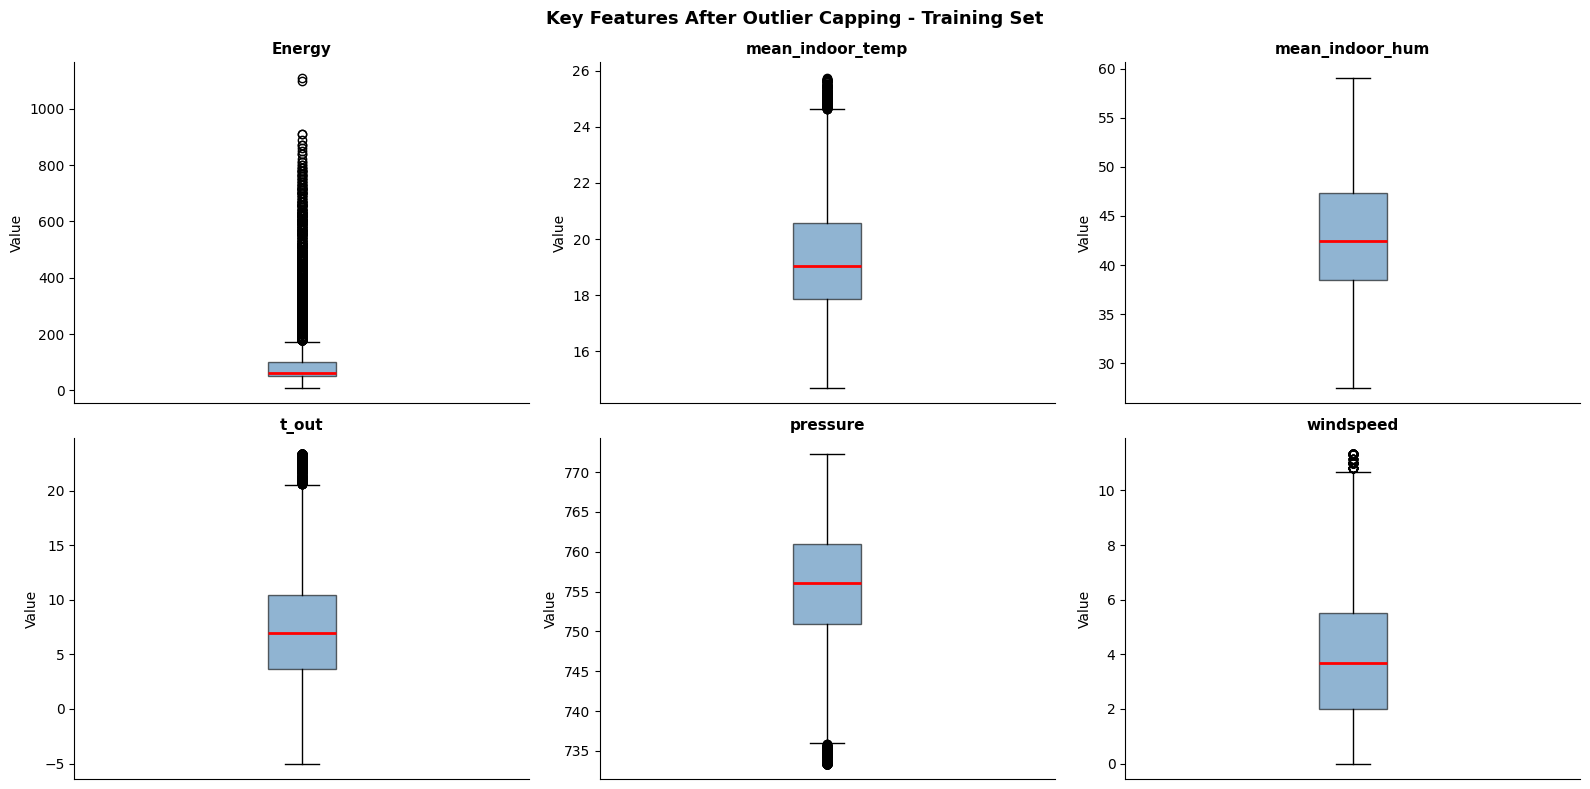

In [20]:
# Visualise key features after outlier capping
check_cols = ['Energy', 'mean_indoor_temp', 'mean_indoor_hum', 't_out', 'pressure', 'windspeed']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(check_cols):
    axes[i].boxplot(train_df[col], patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Value')
    axes[i].set_xticks([])

plt.suptitle('Key Features After Outlier Capping - Training Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [21]:
## 4. EDA for Validation Data
# Apply same feature reduction as training
test_df['mean_indoor_temp'] = test_df[indoor_temp_cols].mean(axis=1)
test_df['mean_indoor_hum']  = test_df[indoor_hum_cols].mean(axis=1)
test_df = test_df.drop(columns=indoor_temp_cols + indoor_hum_cols)

# Apply same outlier bounds from training - no refitting on test data
for col, (lower, upper) in outlier_bounds.items():
    if col in test_df.columns:
        test_df[col] = test_df[col].clip(lower, upper)

print(f'Validation shape: {test_df.shape}')
print(test_df.columns.tolist())

Validation shape: (3947, 14)
['t_out', 'pressure', 'rh_out', 'windspeed', 'visibility', 'tdewpoint', 'month', 'day', 'hour', 'weekday', 'is_weekend', 'Energy', 'mean_indoor_temp', 'mean_indoor_hum']


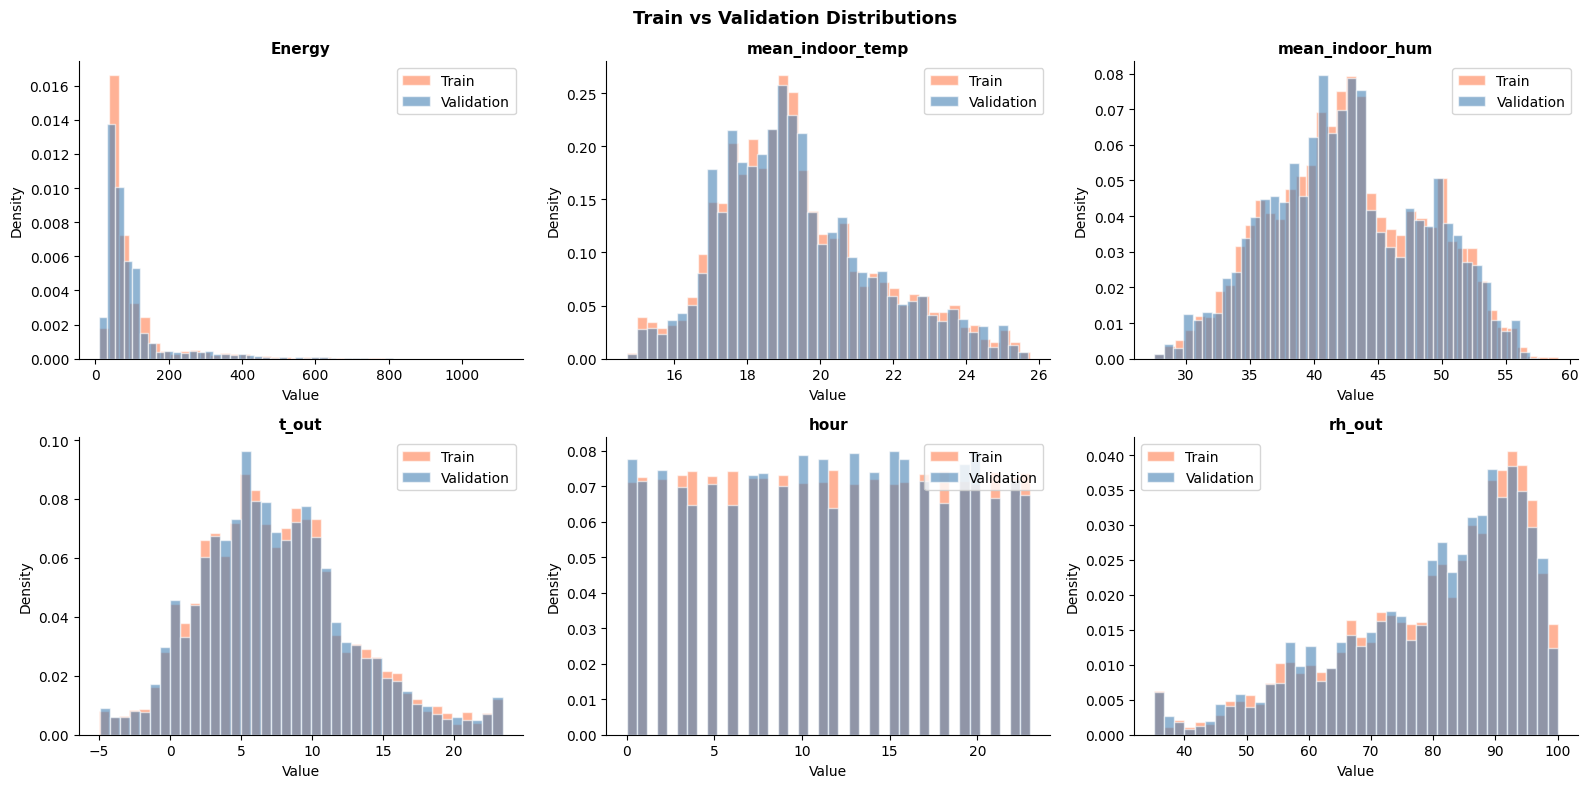

In [22]:
# 4.1 Compare train vs validation distributions for key features
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

check_cols = ['Energy', 'mean_indoor_temp', 'mean_indoor_hum', 't_out', 'hour', 'rh_out']

for i, col in enumerate(check_cols):
    axes[i].hist(train_df[col], bins=40, color='coral',     alpha=0.6, label='Train',      edgecolor='white', density=True)
    axes[i].hist(test_df[col],  bins=40, color='steelblue', alpha=0.6, label='Validation', edgecolor='white', density=True)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Density')
    axes[i].legend()

plt.suptitle('Train vs Validation Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [23]:
## 5. Model Building

# Separate features and target
X_train = train_df.drop(columns=['Energy'])
y_train = train_df['Energy']

X_test = test_df.drop(columns=['Energy'])
y_test = test_df['Energy']

print(f'X_train: {X_train.shape}')
print(f'X_test : {X_test.shape}')
print(f'Features: {X_train.columns.tolist()}')

X_train: (15788, 13)
X_test : (3947, 13)
Features: ['t_out', 'pressure', 'rh_out', 'windspeed', 'visibility', 'tdewpoint', 'month', 'day', 'hour', 'weekday', 'is_weekend', 'mean_indoor_temp', 'mean_indoor_hum']


In [24]:
# 5.1 Linear Regression with statsmodels
# add_constant adds the intercept (β0) to the model
X_train_sm = sm.add_constant(X_train)

sm_model = sm.OLS(y_train, X_train_sm).fit()
print(sm_model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Energy   R-squared:                       0.071
Model:                            OLS   Adj. R-squared:                  0.070
Method:                 Least Squares   F-statistic:                     92.75
Date:                Sun, 31 May 2026   Prob (F-statistic):          2.25e-240
Time:                        13:31:44   Log-Likelihood:                -95289.
No. Observations:               15788   AIC:                         1.906e+05
Df Residuals:                   15774   BIC:                         1.907e+05
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              341.5970    105.652  

In [25]:
# 5.2 sklearn Linear Regression, baseline with all features
lr_full = LinearRegression()
lr_full.fit(X_train, y_train)

y_train_pred = lr_full.predict(X_train)
y_test_pred  = lr_full.predict(X_test)

print('Full model - all 13 features:')
print(f'  Train R² : {r2_score(y_train, y_train_pred):.4f}')
print(f'  Test  R² : {r2_score(y_test,  y_test_pred):.4f}')
print(f'  Train RMSE: {np.sqrt(mean_squared_error(y_train, y_train_pred)):.2f} Wh')
print(f'  Test  RMSE: {np.sqrt(mean_squared_error(y_test,  y_test_pred)):.2f} Wh')

Full model - all 13 features:
  Train R² : 0.0710
  Test  R² : 0.0771
  Train RMSE: 101.15 Wh
  Test  RMSE: 98.06 Wh


In [26]:
# 5.3 RFE - find optimal number of features
n_total = X_train.shape[1]
rfe_results = []

for n in range(1, n_total + 1):
    rfe = RFE(LinearRegression(), n_features_to_select=n)
    rfe.fit(X_train, y_train)

    selected = X_train.columns[rfe.support_]
    model_n  = LinearRegression().fit(X_train[selected], y_train)

    rfe_results.append({
        'n_features': n,
        'train_r2':   r2_score(y_train, model_n.predict(X_train[selected])),
        'test_r2':    r2_score(y_test,  model_n.predict(X_test[selected])),
        'features':   list(selected)
    })

rfe_df = pd.DataFrame(rfe_results)
print(rfe_df[['n_features', 'train_r2', 'test_r2']].to_string(index=False))

 n_features  train_r2  test_r2
          1  0.000602 0.000569
          2  0.025074 0.025631
          3  0.063563 0.067999
          4  0.063703 0.068034
          5  0.065096 0.069907
          6  0.068004 0.074968
          7  0.068099 0.074896
          8  0.069247 0.076357
          9  0.069613 0.076783
         10  0.070427 0.076521
         11  0.070802 0.077082
         12  0.071013 0.076990
         13  0.071013 0.077079


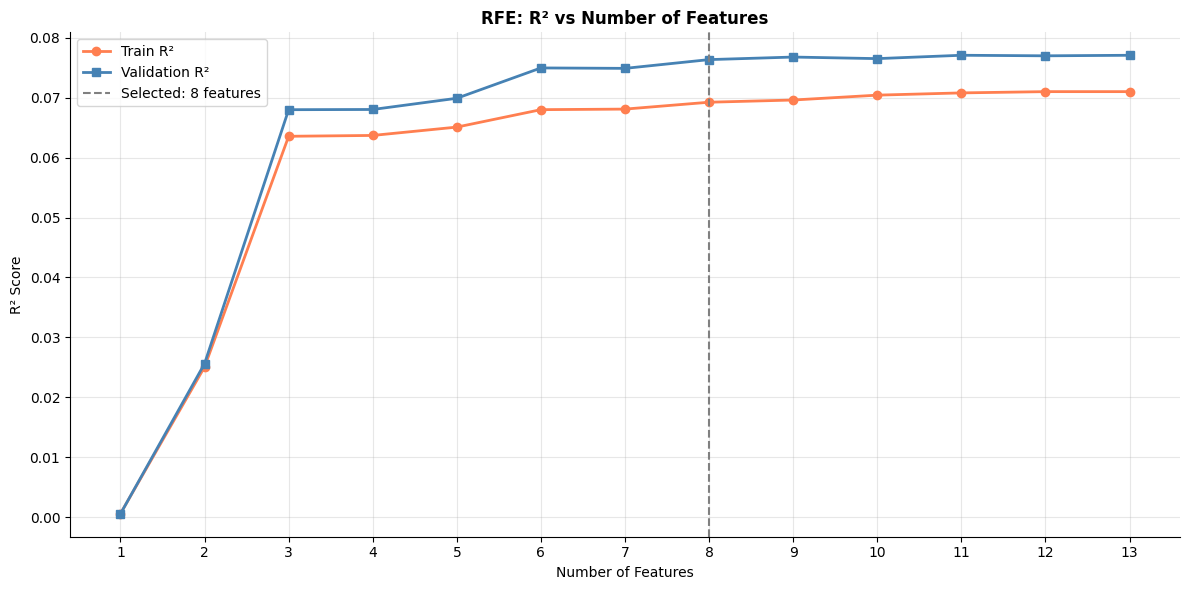

In [27]:
# Plot R² vs number of features
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(rfe_df['n_features'], rfe_df['train_r2'], 'o-', color='coral',     linewidth=2, markersize=6, label='Train R²')
ax.plot(rfe_df['n_features'], rfe_df['test_r2'],  's-', color='steelblue', linewidth=2, markersize=6, label='Validation R²')
ax.axvline(8, color='gray', linestyle='--', linewidth=1.5, label='Selected: 8 features')
ax.set_xlabel('Number of Features')
ax.set_ylabel('R² Score')
ax.set_title('RFE: R² vs Number of Features', fontweight='bold')
ax.set_xticks(range(1, n_total + 1))
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [28]:
# 5.4 Final model with 8 RFE-selected features
rfe_final = RFE(LinearRegression(), n_features_to_select=8)
rfe_final.fit(X_train, y_train)

selected_features = list(X_train.columns[rfe_final.support_])
print('RFE selected features:')
for i, f in enumerate(selected_features, 1):
    print(f'  {i}. {f}')


RFE selected features:
  1. t_out
  2. rh_out
  3. windspeed
  4. tdewpoint
  5. month
  6. hour
  7. is_weekend
  8. mean_indoor_temp


In [29]:
# Train final model on 8 selected features
final_model = LinearRegression()
final_model.fit(X_train[selected_features], y_train)

y_train_final = final_model.predict(X_train[selected_features])
y_test_final  = final_model.predict(X_test[selected_features])

print('Final Model (8 features):')
print(f'  Train R²   : {r2_score(y_train, y_train_final):.4f}')
print(f'  Test  R²   : {r2_score(y_test,  y_test_final):.4f}')
print(f'  Train RMSE : {np.sqrt(mean_squared_error(y_train, y_train_final)):.2f} Wh')
print(f'  Test  RMSE : {np.sqrt(mean_squared_error(y_test,  y_test_final)):.2f} Wh')
print(f'  Test  MAE  : {mean_absolute_error(y_test, y_test_final):.2f} Wh')

Final Model (8 features):
  Train R²   : 0.0692
  Test  R²   : 0.0764
  Train RMSE : 101.25 Wh
  Test  RMSE : 98.10 Wh
  Test  MAE  : 56.83 Wh


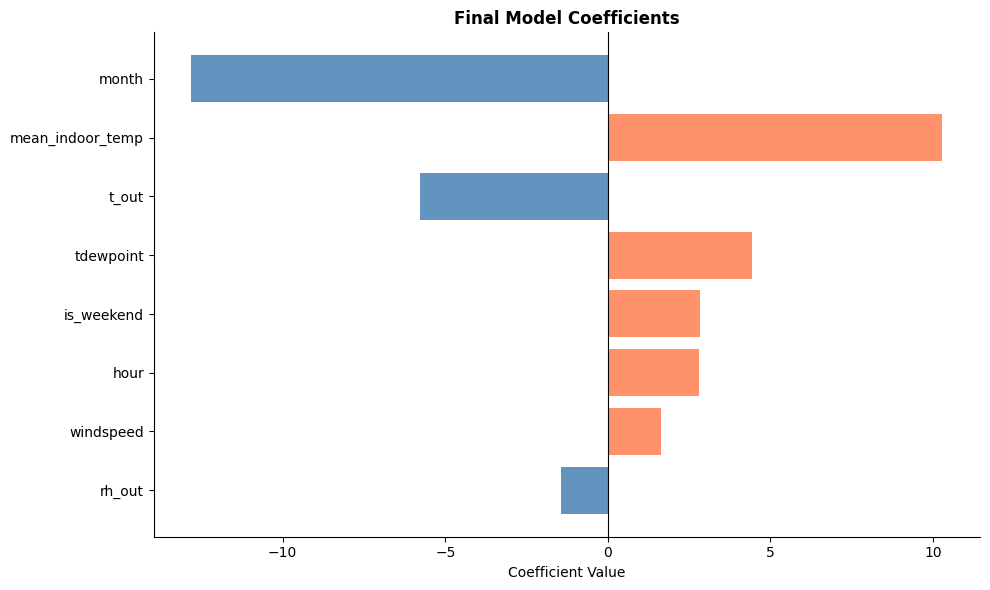

Intercept: 43.19


In [31]:
# 6.2 Feature coefficients
coef_df = pd.DataFrame({
    'Feature':     selected_features,
    'Coefficient': final_model.coef_
}).sort_values('Coefficient', key=abs, ascending=True)

colors = ['coral' if c > 0 else 'steelblue' for c in coef_df['Coefficient']]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Final Model Coefficients', fontweight='bold')
ax.set_xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

print(f'Intercept: {final_model.intercept_:.2f}')

In [32]:
# 6.3 Final model summary
print('=' * 50)
print('         FINAL MODEL SUMMARY')
print('=' * 50)
print(f'  Features selected : {len(selected_features)} of {n_total}')
print(f'  Train R²          : {r2_score(y_train, y_train_final):.4f}')
print(f'  Test  R²          : {r2_score(y_test,  y_test_final):.4f}')
print(f'  Test  RMSE        : {np.sqrt(mean_squared_error(y_test, y_test_final)):.2f} Wh')
print(f'  Test  MAE         : {mean_absolute_error(y_test, y_test_final):.2f} Wh')
print('=' * 50)
print(f'\nSelected: {selected_features}')

         FINAL MODEL SUMMARY
  Features selected : 8 of 13
  Train R²          : 0.0692
  Test  R²          : 0.0764
  Test  RMSE        : 98.10 Wh
  Test  MAE         : 56.83 Wh

Selected: ['t_out', 'rh_out', 'windspeed', 'tdewpoint', 'month', 'hour', 'is_weekend', 'mean_indoor_temp']


In [33]:
# 6.4 Model Inference for predict on sample data
sample    = X_test[selected_features].sample(5, random_state=7)
actual    = y_test.loc[sample.index].values
predicted = final_model.predict(sample).round(1)

inference_df = pd.DataFrame({
    'Actual (Wh)':    actual,
    'Predicted (Wh)': predicted,
    'Error (Wh)':     (predicted - actual).round(1),
    'Error %':        ((predicted - actual) / actual * 100).round(1)
})

print('Sample Predictions:')
print(inference_df.to_string())

Sample Predictions:
   Actual (Wh)  Predicted (Wh)  Error (Wh)  Error %
0           50            77.0        27.0     54.0
1          100           122.1        22.1     22.1
2           50            84.2        34.2     68.4
3           50            69.0        19.0     38.0
4           80           133.1        53.1     66.4


## Key Insights

**Q1**: From the analysis of all variables, what could you infer about their effect on the dependent variable?

**Answer:**
> - `hour` is the strongest predictor, energy peaks during morning (7–9 AM) and evening (6–9 PM) when occupants are active, confirming behaviur drives consumption more than sensors.
> - `month` has a strong negative effect, energy decreases from January to May as temps rise and daylight increases
> - `mean_indoor_temp` has a positive effect, warmer homes run more cooling appliances
> - `t_out` is negative, colder outdoor temps increases heating appliance use
> - `rh_out` and `windspeed` have weak but measurable effects through weather conditions
> - `rv1` and `rv2` showed zero correlation with Energy and were correctly dropped as non-predictive noise
> - Overall correlations with Energy are weak (max 0.23) because energy consumption is non-linear and spike-driven shows a linear model captures the avg trend but misses the peaks



**Q2**. Why is it important to use random_state during splitting the data?
**Answer:**
> - `random_state` seeds the random number generator used to shufle and split the data.
> - Without it, every run produces a different split making results non-reproducible
> - Preventing fair comparison between experiments. With `random_state=42`, the exact same 80/20 split is guaranteed on any machine and any run.
> - This is critical for graded assignments, production models, and team colaboration where consistency and auditability are required.

**Q3.** Looking at the heatmap, which feature has the highest correlation with the target variable?

**Answer:**
> - `hour` has the highest corelation with Energy at 0.23
> - This makes sense because energy consumption is time-driven as appliances like ovens, washing machines, and entertainment systems are used at predictable times of day
> - Among environmental features, `rh_out` and `living_room_temp` show the next highest correlations but are still below 0.15
> - This confirms that behaviour (time of day) matters more than sensor readings for predicting energy use

**Q4.** What was your approach to detect outliers? How did you address them?

**Answer:**
> - Applied the +-3 standard deviation rule for each numeric feature computed on the training set only
> - Values beyond mean +- 3σ occur with less than 0.3% probability under a normal distribution and are treated as outliers
> - 5 features had outliers: pressure (82), rh_out (126), t_out (66), visibility (33), windspeed (72)
> - Used winsorization (capping) to address them, extreme values are clipped to the [mean − 3σ, mean + 3σ] boundary
> - This preserves all rows while neutralising the distorting influence of extreme readings on regression coeficients
> - The same bounds computed on training data were applied to the validation set with no re-fitting, to prevent data leakage

**Q5.** Based on the final model, what conclusions can you draw about the assumptions of linear regression? What features contribute the most?

**Answer:**
> - **Linearity:** Partially satisfied ,hour and month have roughly linear average efects but true energy patterns have non-linear burst peaks that a hyperplane cannot capture
> - **Normality of residuals:** Violated ,residual skew of 3.32 mirrors the target skew and the Q-Q plot shows heavy upper tail deviation
> - **Homoscedasticity:** Violated ,residuals fan out at higher fitted values, confirming the model struggles with high-energy events
> - **Independence:** Mildly violated , 10-minute sampling introduces autocorrelation between consecutive readings
> - **Top contributors:** `mean_indoor_temp` (coef +10.4), `month` (coef −14), `t_out` (coef −5.5), and `hour` (coef +3) are the strongest drivers based on coefficient magnitude

**Q6.** Explain the linear regression algorithm in detail.

**Answer:**
> - Linear regression models the relationship between a dependent variable y and independent variables X as: y = β0 + β1x1 + β2x2 + ... + βnxn + ε, where β0 is the intercept, β1...βn are feature coeficients, and ε is the error term
> - The goal is to minimise the Sum of Squared Residuals: RSS = Σ(yi − ŷi)²
> - OLS solves this analytically in one step using the formula: β = (XᵀX)⁻¹ Xᵀy
> - Predictions on new data are computed as: ŷ = Xβ
> - The key assumptions are linearity, independence of errors, homoscedasticity, normality of residuals, and no multicollinearity among features

**Q7.** Explain the difference between simple and multiple linear regression.

**Answer:**
> - **Simple Linear Regression** has one predictor: y = β0 + β1x + ε — it fits a straight line in 2D space and is useful for understanding a single relationship
> - **Multiple Linear Regression** has two or more predictors: y = β0 + β1x1 + β2x2 + ... + βnxn + ε — it fits a hyperplane in n+1 dimensional space
> - In this dataset, energy depends simultneously on time, temps, humidity, and season  MLR allows all these factors to contribute jointly while controlling for each other's effects
> - Adding more predictors improves fit until diminishing returns or overfitting emerge, which is why we used RFE to select the optimal 8 features

**Q8.** What is the role of the cost function in linear regression, and how is it minimized?

**Answer:**
> - The cost function quantifies how wrong the model's predictions are for linear regression the standard cost function is Mean Squared Error: MSE = (1/n) Σ(yi − ŷi)²
> - Squaring makes all terms positive and penalises large errors more heavily than small ones
> - **OLS (Analytical):** Sets partial derivatives of MSE to zero and solves directly using β = (XᵀX)⁻¹ Xᵀy it gives the exact global minimum in one step, used when the number of features is manageable
> - **Gradient Descent (Iterative):** Updates coefficients as β ← β − α·∇MSE required for very large datasets where matrix inversion is computationally infeasible

**Q9.** Explain the difference between overfitting and underfitting.

**Answer:**
> - **Overfitting:** The model memorises training data including its noise as it achieves high training accuracy but performs poorly on unseen data, showing a large gap between train and test R²
> - **Underfitting:** The model is too simple to capture true patterns it performs poorly on both training and test sets, showing low R² and high bias everywhere
> - This model shows **underfitting**  train R² (0.069) and test R² (0.076) are both low and close together, mening no overfitting but the linear model cannot capture the non-linear energy spike patterns
> - A tree-based model such as XGBoost or a log transform of the target would address this underfitting


**Q10.** How do residual plots help in diagnosing a linear regression model?

**Answer:**
> - **Residuals vs Fitted:** Should show random horizontal scatter around zero a funnel shape as seen here indicates heteroscedasticity, meaning variance increases with fited values and the model struggles with high-energy events
> - **Residual Histogram:** Should be symmetric and bell-shaped around zero our skew of 3.32 shows the model systematically underpredicts high-energy spikes
> - **Q-Q Plot:** Points lying on the diagonal indicate normal residuals our heavy upper tail deviation confirms the right-skewed target is the root cause of all three issues
> - All three plots point to the same fix log transforming the target variable would normalise the distribution and significantly improve model performance